# Homework 1 — Data Preparation (4 Points)

**Dataset:** [UC Merced Land Use](https://huggingface.co/datasets/blanchon/UC_Merced) — 21 land use classes from aerial imagery.

**Tasks:**
1. Load the dataset from HuggingFace
2. Split into **70% Training / 15% Validation / 15% Test** (stratified)
3. Save to disk in ImageFolder format
4. Show **1 sample image per class**
5. Print the **number of samples per class per split**

## 1. Load the UC Merced Dataset

In [1]:
from datasets import load_dataset

# TODO: Load the UC Merced dataset (1 line)
UC_Merced = load_dataset("blanchon/UC_Merced")

print(UC_Merced)
print(f"\nClass names: {UC_Merced['train'].features['label'].names}")
print(f"Number of classes: {UC_Merced['train'].features['label'].num_classes}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/416M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2100 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 2100
    })
})

Class names: ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']
Number of classes: 21


## 2. Split and Save to Disk

In [2]:
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split

TARGET_BASE = Path("PrepData")

# Get class names
class_names = UC_Merced["train"].features["label"].names

# Combine all HuggingFace splits into one pool
all_images = []
all_labels = []
for split_name in UC_Merced:
    split_data = UC_Merced[split_name]
    all_images.extend(split_data["image"])
    all_labels.extend(split_data["label"])

print(f"Total samples: {len(all_images)}")

# TODO: Split into 70% train, 15% val, 15% test (stratified)
# Step 1: Split into train (70%) and temp (30%)
train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(
    all_images, all_labels, test_size=0.3, stratify=all_labels, random_state=42
)
# Step 2: Split temp into val (50% of 30% = 15%) and test (50% of 30% = 15%)
val_imgs, test_imgs, val_labels, test_labels = train_test_split(
    temp_imgs, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

print(f"Train: {len(train_imgs)}, Val: {len(val_imgs)}, Test: {len(test_imgs)}")

Total samples: 2100
Train: 1470, Val: 315, Test: 315


In [3]:
# Save images to disk in ImageFolder format (provided — just run this cell)
splits = {
    "Training": (train_imgs, train_labels),
    "Validation": (val_imgs, val_labels),
    "Test": (test_imgs, test_labels),
}

if TARGET_BASE.exists():
    shutil.rmtree(TARGET_BASE)

for split_name, (images, labels) in splits.items():
    for idx, (img, label) in enumerate(zip(images, labels)):
        cls_name = class_names[label]
        dest_dir = TARGET_BASE / split_name / cls_name
        dest_dir.mkdir(parents=True, exist_ok=True)
        img.convert("RGB").save(dest_dir / f"{idx:04d}.jpg")
    print(f"  {split_name}: {len(images)} images")

print("\nDone! Dataset saved to PrepData/")

  Training: 1470 images
  Validation: 315 images
  Test: 315 images

Done! Dataset saved to PrepData/


## 3. Show 1 Sample Image per Class

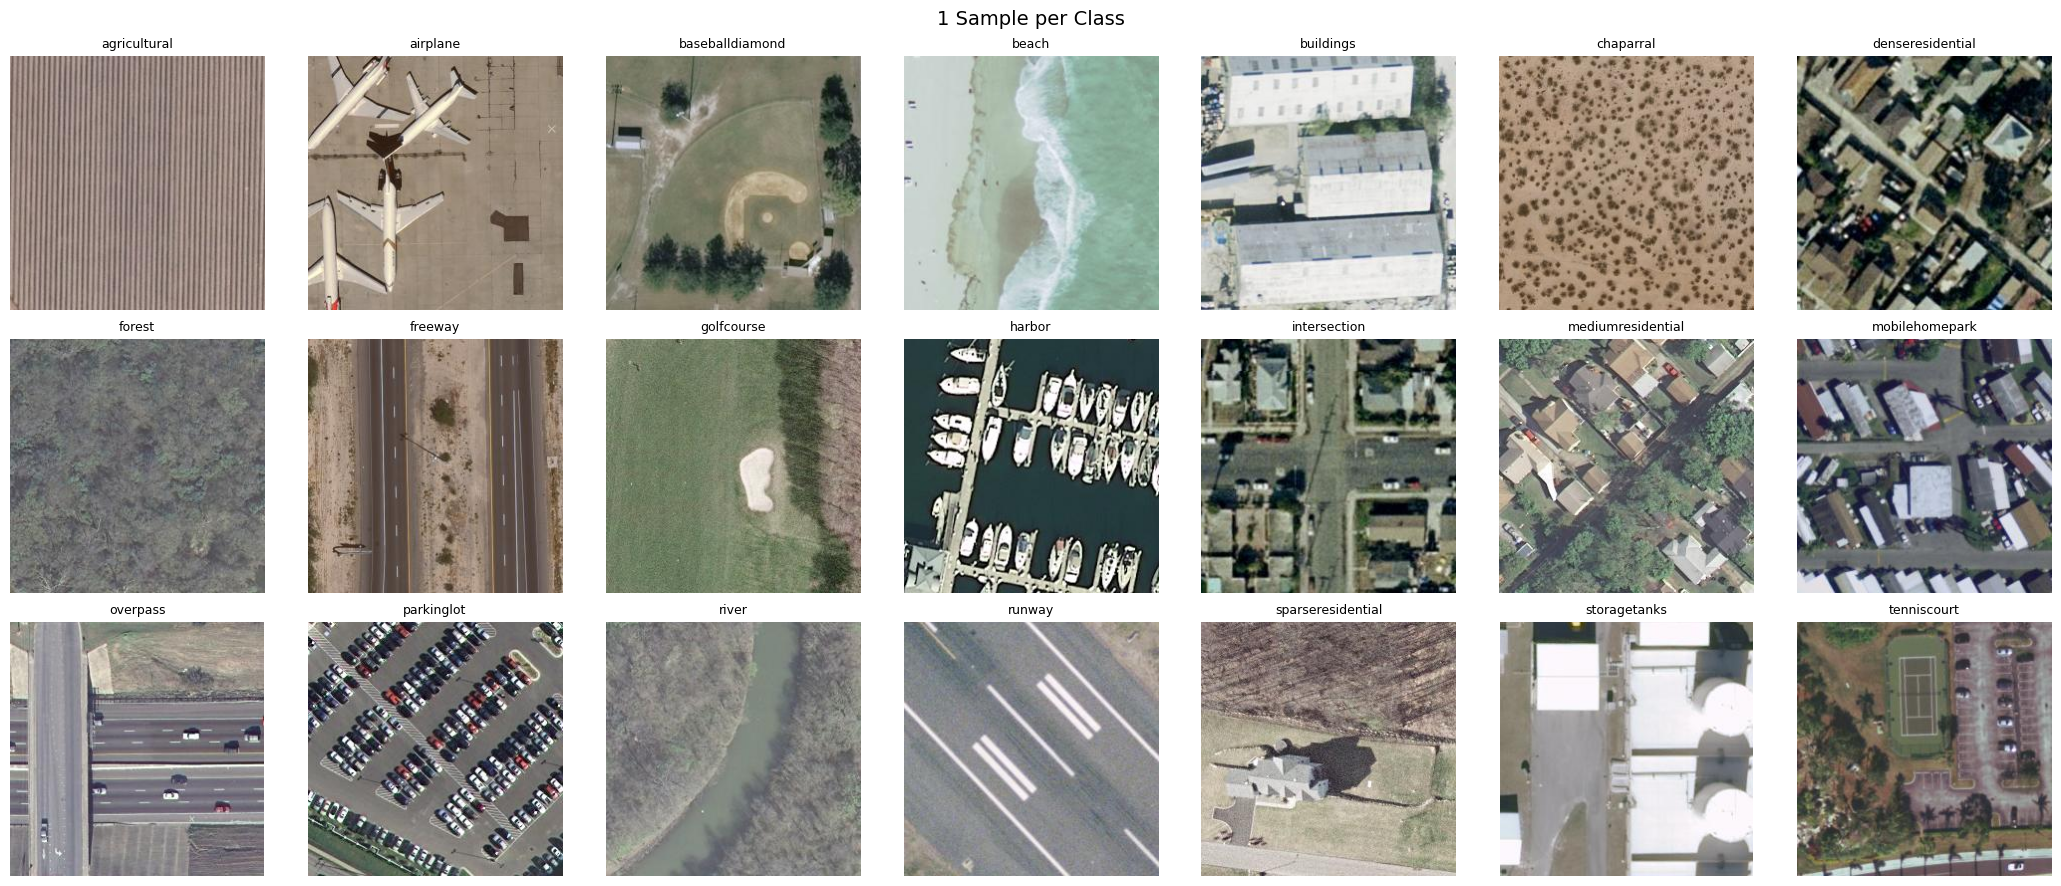

In [4]:
import matplotlib.pyplot as plt
from torchvision import datasets

train_ds = datasets.ImageFolder("PrepData/Training")

# TODO: Create a grid of subplots to show 1 image per class
# Hint: 3 rows x 7 cols = 21 slots, one for each class
fig, axes = plt.subplots(3, 7, figsize=(21, 9))
axes = axes.flatten()

for cls_idx, cls_name in enumerate(train_ds.classes):
    # Find first image of this class
    sample_idx = train_ds.targets.index(cls_idx)
    img, _ = train_ds[sample_idx]

    axes[cls_idx].imshow(img)
    axes[cls_idx].set_title(cls_name, fontsize=9)
    axes[cls_idx].axis('off')

plt.suptitle("1 Sample per Class", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Print Number of Samples per Class per Split

In [5]:
from collections import Counter

for split_name in ["Training", "Validation", "Test"]:
    ds = datasets.ImageFolder(f"PrepData/{split_name}")
    counts = Counter(ds.targets)

    print(f"\n=== {split_name} ({len(ds)} total) ===")
    for idx in sorted(counts.keys()):
        print(f"  {ds.classes[idx]:30s} {counts[idx]:4d}")


=== Training (1470 total) ===
  agricultural                     70
  airplane                         70
  baseballdiamond                  70
  beach                            70
  buildings                        70
  chaparral                        70
  denseresidential                 70
  forest                           70
  freeway                          70
  golfcourse                       70
  harbor                           70
  intersection                     70
  mediumresidential                70
  mobilehomepark                   70
  overpass                         70
  parkinglot                       70
  river                            70
  runway                           70
  sparseresidential                70
  storagetanks                     70
  tenniscourt                      70

=== Validation (315 total) ===
  agricultural                     15
  airplane                         15
  baseballdiamond                  15
  beach                  